## Feature Engineering(FE) Bag of Words(BoW)


In [53]:
#Merging Datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fake = pd.read_csv('../data/Fake.csv')
true = pd.read_csv('../data/True.csv')

fake['label'] = 0
true['label'] = 1


df = pd.concat([fake, true], ignore_index=True)

df.head()


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [56]:
import re
from IPython.display import display, Markdown

# --- Code Explanation (optional, also can keep as Markdown cell above) ---
display(Markdown("### Preprocessing Text Data\n"
                 "- Converting text to lowercase\n"
                 "- Removing non-word characters / special characters and punctuation (e.g., . , ! ? ; : \" ' ( ) [ ] { } @ # $ % & * etc.)\n"
                 "- Removing extra spaces"))

# --- Preprocessing Function ---
def preprocess_text(text):
    text = text.lower()  # converting text to lowercase
    text = re.sub(r'\W', ' ', text)  # removing non-word characters
    text = re.sub(r'\s+', ' ', text).strip()  # removes extra spaces
    return text

# --- Apply preprocessing to the text column with numbers ---
df['clean_text_with_num'] = df['text'].apply(preprocess_text)

# --- Display output ---
display(df[['text', 'clean_text_with_num']].head())

# --- Explanation below output ---
display(Markdown("**Explanation:** The `clean_text_with_num` column now contains the preprocessed version of the text.\n"
                 "- All letters are lowercase.\n"
                 "- Special characters, punctuation, and extra spaces have been removed.\n"
                 "- This column is ready for tokenization and Bag of Words feature extraction."))


### Preprocessing Text Data
- Converting text to lowercase
- Removing non-word characters / special characters and punctuation (e.g., . , ! ? ; : " ' ( ) [ ] { } @ # $ % & * etc.)
- Removing extra spaces

,text,clean_text_with_num
0,Donald Trump just couldn t wish all Americans ...,donald trump just couldn t wish all americans ...
1,House Intelligence Committee Chairman Devin Nu...,house intelligence committee chairman devin nu...
2,"On Friday, it was revealed that former Milwauk...",on friday it was revealed that former milwauke...
3,"On Christmas day, Donald Trump announced that ...",on christmas day donald trump announced that h...
4,Pope Francis used his annual Christmas Day mes...,pope francis used his annual christmas day mes...


**Explanation:** The `clean_text_with_num` column now contains the preprocessed version of the text.
- All letters are lowercase.
- Special characters, punctuation, and extra spaces have been removed.
- This column is ready for tokenization and Bag of Words feature extraction.

In [57]:
import re
from IPython.display import display, Markdown

# --- Code Explanation (optional, can also be a Markdown cell above) ---
display(Markdown("### Preprocessing Text Data (Without Numbers)\n"
                 "- Converting text to lowercase\n"
                 "- Removing non-word characters, punctuation, and numbers\n"
                 "- Removing extra spaces"))

# --- Preprocessing Function ---
def preprocess_text(text):
    text = text.lower()  # converting text to lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)  # remove non-word characters and numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

# --- Apply preprocessing to the text column without numbers ---
df['clean_text_with_no_num'] = df['text'].apply(preprocess_text)

# --- Display output ---
display(df[['text', 'clean_text_with_no_num']].head())

# --- Explanation below output ---
display(Markdown("**Explanation:** The `clean_text_with_no_num` column now contains the preprocessed version of the text without numbers.\n"
                 "- All letters are lowercase.\n"
                 "- Special characters, punctuation, and numbers have been removed.\n"
                 "- Extra spaces have been cleaned up.\n"
                 "- This column is ready for Bag of Words feature extraction without numerical data."))


### Preprocessing Text Data (Without Numbers)
- Converting text to lowercase
- Removing non-word characters, punctuation, and numbers
- Removing extra spaces

,text,clean_text_with_no_num
0,Donald Trump just couldn t wish all Americans ...,donald trump just couldn t wish all americans ...
1,House Intelligence Committee Chairman Devin Nu...,house intelligence committee chairman devin nu...
2,"On Friday, it was revealed that former Milwauk...",on friday it was revealed that former milwauke...
3,"On Christmas day, Donald Trump announced that ...",on christmas day donald trump announced that h...
4,Pope Francis used his annual Christmas Day mes...,pope francis used his annual christmas day mes...


**Explanation:** The `clean_text_with_no_num` column now contains the preprocessed version of the text without numbers.
- All letters are lowercase.
- Special characters, punctuation, and numbers have been removed.
- Extra spaces have been cleaned up.
- This column is ready for Bag of Words feature extraction without numerical data.

In [58]:
from sklearn.feature_extraction.text import CountVectorizer
from IPython.display import display, Markdown

# --- Code Explanation (Markdown above code) ---
display(Markdown("### Building Bag of Words (BoW) Matrix for Text With Numbers\n"
                 "- Using `CountVectorizer` from sklearn to convert text into a BoW matrix.\n"
                 "- Keeping the top 5000 most frequent words.\n"
                 "- Each row = one article, each column = one word feature.\n"
                 "- Values = word counts in the article."))

# --- BoW Construction ---
vectorizer = CountVectorizer(max_features=5000)  # top 5000 frequent words
X = vectorizer.fit_transform(df['clean_text_with_num']).toarray()

# --- Display output ---
print("BoW Matrix shape:", X.shape)
print("Top 20 features:", vectorizer.get_feature_names_out()[:20])

# --- Explanation below output ---
display(Markdown("**Explanation:**\n"
                 "- BoW Matrix shape: {} → {} articles (rows) and {} features (columns).\n"
                 "- Top 20 features shown are the most frequent words across all articles.\n"
                 "- Many words are numeric because this text version **kept numbers** during preprocessing."
                 .format(X.shape, X.shape[0], X.shape[1])))


### Building Bag of Words (BoW) Matrix for Text With Numbers
- Using `CountVectorizer` from sklearn to convert text into a BoW matrix.
- Keeping the top 5000 most frequent words.
- Each row = one article, each column = one word feature.
- Values = word counts in the article.

BoW Matrix shape: (44898, 5000)
Top 20 features: ['00' '000' '10' '100' '11' '12' '120' '13' '14' '15' '150' '16' '17' '18'
 '19' '1980s' '1990s' '1992' '1993' '1994']


**Explanation:**
- BoW Matrix shape: (44898, 5000) → 44898 articles (rows) and 5000 features (columns).
- Top 20 features shown are the most frequent words across all articles.
- Many words are numeric because this text version **kept numbers** during preprocessing.

In [59]:
from sklearn.feature_extraction.text import CountVectorizer
from IPython.display import display, Markdown

# --- Code Explanation (Markdown above code) ---
display(Markdown("### Building Bag of Words (BoW) Matrix for Text Without Numbers\n"
                 "- Using `CountVectorizer` from sklearn to convert text into a BoW matrix.\n"
                 "- Keeping the top 5000 most frequent words.\n"
                 "- Each row = one article, each column = one word feature.\n"
                 "- Values = word counts in the article.\n"
                 "- Numbers have been removed during preprocessing, so only alphabetic tokens remain."))

# --- BoW Construction ---
vectorizer = CountVectorizer(max_features=5000)  # top 5000 frequent words
X = vectorizer.fit_transform(df['clean_text_with_no_num']).toarray()

# --- Display output ---
print("BoW Matrix shape:", X.shape)
print("Top 20 features:", vectorizer.get_feature_names_out()[:20])

# --- Explanation below output ---
display(Markdown("**Explanation:**\n"
                 "- BoW Matrix shape: {} → {} articles (rows) and {} features (columns).\n"
                 "- Top 20 features shown are the most frequent alphabetic words across all articles.\n"
                 "- Numbers are excluded because this version of the text **removed numeric characters**."
                 .format(X.shape, X.shape[0], X.shape[1])))


### Building Bag of Words (BoW) Matrix for Text Without Numbers
- Using `CountVectorizer` from sklearn to convert text into a BoW matrix.
- Keeping the top 5000 most frequent words.
- Each row = one article, each column = one word feature.
- Values = word counts in the article.
- Numbers have been removed during preprocessing, so only alphabetic tokens remain.

BoW Matrix shape: (44898, 5000)
Top 20 features: ['abadi' 'abandon' 'abandoned' 'abbas' 'abc' 'abdullah' 'abe' 'abedin'
 'ability' 'able' 'abortion' 'abortions' 'about' 'above' 'abroad'
 'absence' 'absolute' 'absolutely' 'absurd' 'abu']


**Explanation:**
- BoW Matrix shape: (44898, 5000) → 44898 articles (rows) and 5000 features (columns).
- Top 20 features shown are the most frequent alphabetic words across all articles.
- Numbers are excluded because this version of the text **removed numeric characters**.

In [62]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
from IPython.display import display, Markdown

# --- Code Explanation (Markdown above code) ---
display(Markdown("### Calculating Word Frequencies\n"
                 "- We compute word frequencies for both text columns: with numbers and without numbers.\n"
                 "- Stopwords (common words like 'the', 'and', 'is') are removed to focus on meaningful words.\n"
                 "- Each row in the resulting table shows a word and its frequency across all articles."))

# --- Download stopwords if needed ---
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# --- Function to get word frequencies ---
def get_word_freq(series):
    """Return a DataFrame of word frequencies for a given text column."""
    all_words = " ".join(series).split()
    filtered_words = [word for word in all_words if word not in stop_words]
    word_freq = Counter(filtered_words)
    return pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

# --- Compute frequencies for both text versions ---
freq_with_num = get_word_freq(df['clean_text_with_num'])
freq_no_num = get_word_freq(df['clean_text_with_no_num'])

# --- Display outputs ---
display(Markdown("**Word frequency table (with numbers):**"))
display(freq_with_num.head())

display(Markdown("**Word frequency table (without numbers):**"))
display(freq_no_num.head())

# --- Explanation below output ---
display(Markdown("**Explanation:**\n"
                 "NOTE: The two tables are truncated to show only the first few and last few rows\n"
                 "- The first table shows the most frequent words including numbers.\n"
                 "- The second table shows the most frequent words with numbers removed.\n"
                 "- Stopwords were excluded to highlight meaningful content words.\n"
                 "- These tables are used for selecting top words for BoW and visualization."))


### Calculating Word Frequencies
- We compute word frequencies for both text columns: with numbers and without numbers.
- Stopwords (common words like 'the', 'and', 'is') are removed to focus on meaningful words.
- Each row in the resulting table shows a word and its frequency across all articles.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\OG\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Word frequency table (with numbers):**

,Word,Frequency
1,trump,134000
270,said,132825
33,president,55892
76,would,55167
1109,u,54290


**Word frequency table (without numbers):**

,Word,Frequency
1,trump,134641
253,said,132825
33,president,55990
71,would,55171
1074,u,54559


**Explanation:**
NOTE: The two tables are truncated to show only the first few and last few rows
- The first table shows the most frequent words including numbers.
- The second table shows the most frequent words with numbers removed.
- Stopwords were excluded to highlight meaningful content words.
- These tables are used for selecting top words for BoW and visualization.

### Visualizing Top 10 Most Frequent Words
- We plot the top 10 words for both text columns: with numbers and without numbers.
- Bar height = word frequency.
- X-axis = word, Y-axis = frequency.
- This allows us to quickly compare the most common words in both versions of the text.

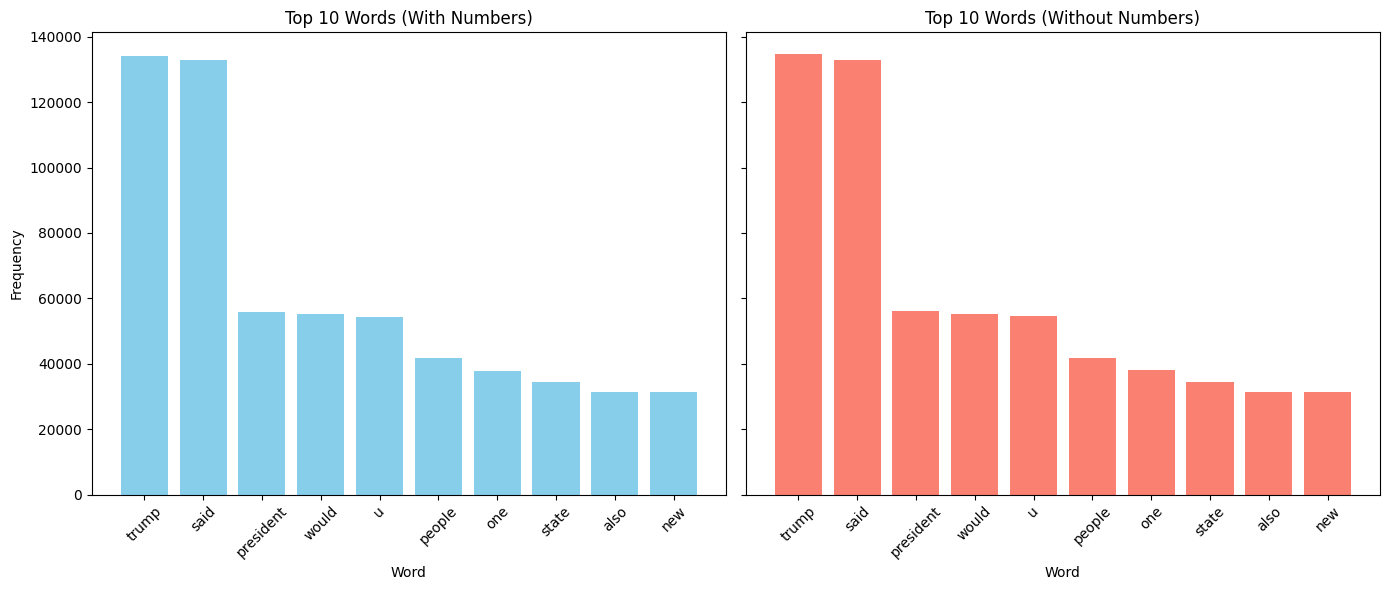

**Explanation:**
- Left plot shows the top 10 words **including numbers**.
- Right plot shows the top 10 words **with numbers removed**.
- This visualization helps identify the most frequent words in each version of the dataset.
- Frequencies are based on the cleaned and preprocessed text, excluding stopwords.

In [63]:
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# --- Code Explanation (Markdown above code) ---
display(Markdown("### Visualizing Top 10 Most Frequent Words\n"
                 "- We plot the top 10 words for both text columns: with numbers and without numbers.\n"
                 "- Bar height = word frequency.\n"
                 "- X-axis = word, Y-axis = frequency.\n"
                 "- This allows us to quickly compare the most common words in both versions of the text."))

# --- Select Top 10 Words ---
top10_with_num = freq_with_num.head(10)
top10_no_num = freq_no_num.head(10)

# --- Plot Side-by-Side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot for clean_text_with_num
axes[0].bar(top10_with_num['Word'], top10_with_num['Frequency'], color='skyblue')
axes[0].set_title("Top 10 Words (With Numbers)")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Word")
axes[0].tick_params(axis='x', rotation=45)

# Plot for clean_text_with_no_num
axes[1].bar(top10_no_num['Word'], top10_no_num['Frequency'], color='salmon')
axes[1].set_title("Top 10 Words (Without Numbers)")
axes[1].set_xlabel("Word")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# --- Explanation below plot ---
display(Markdown("**Explanation:**\n"
                 "- Left plot shows the top 10 words **including numbers**.\n"
                 "- Right plot shows the top 10 words **with numbers removed**.\n"
                 "- This visualization helps identify the most frequent words in each version of the dataset.\n"
                 "- Frequencies are based on the cleaned and preprocessed text, excluding stopwords."))


### Bag of Words (BoW) Heatmap for Top 10 Words
- Visualize the presence (1) or absence (0) of the top 10 words in the first 5 articles.
- Green = word is present, Red = word is absent.
- Two heatmaps: one for text **with numbers**, one for text **without numbers**.

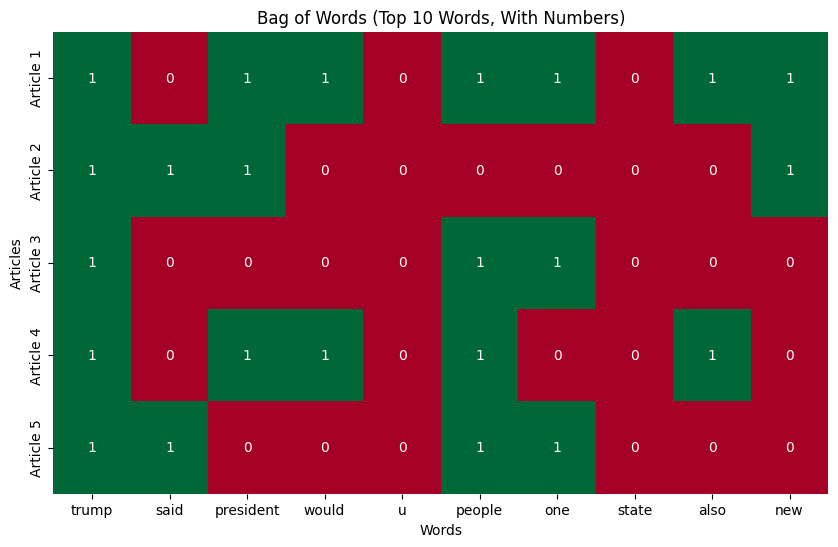

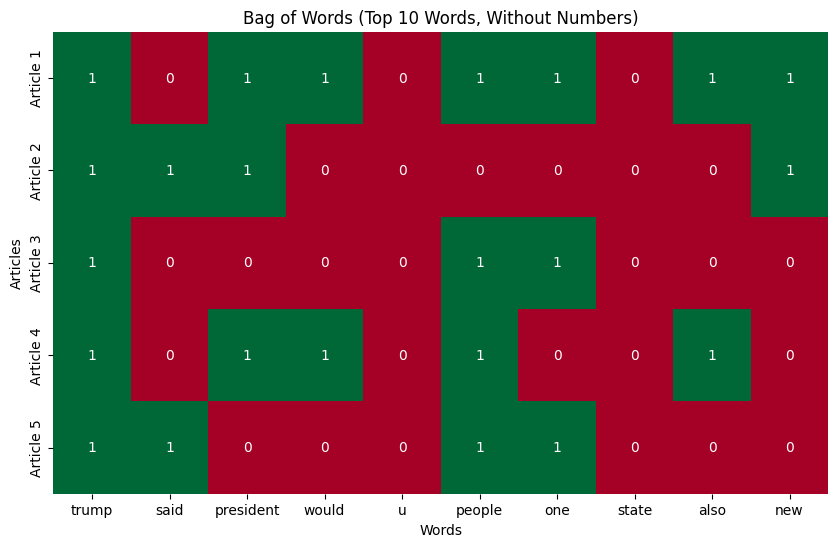

**Explanation:**
- Heatmaps show whether the top 10 words are present in each of the first 5 articles.
- Left heatmap: includes numbers; right heatmap: numbers removed.
- `1` = word is present, `0` = word is absent.
- This visually demonstrates how frequently the top words appear across sample articles.

In [64]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# --- Explanation above code ---
display(Markdown("### Bag of Words (BoW) Heatmap for Top 10 Words\n"
                 "- Visualize the presence (1) or absence (0) of the top 10 words in the first 5 articles.\n"
                 "- Green = word is present, Red = word is absent.\n"
                 "- Two heatmaps: one for text **with numbers**, one for text **without numbers**."))

# --- Prepare Top 10 Words ---
top10_words_with_num = freq_with_num['Word'].head(10).tolist()
top10_words_no_num = freq_no_num['Word'].head(10).tolist()

# --- BoW for WITH numbers ---
dataset_with = df['clean_text_with_num'].head(5)  # first 5 articles for visualization
X_with = []
for text in dataset_with:
    words = text.split()  # simple split instead of word_tokenize
    vector = [1 if word in words else 0 for word in top10_words_with_num]
    X_with.append(vector)
X_with = np.asarray(X_with)

plt.figure(figsize=(10, 6))
sns.heatmap(X_with, cmap='RdYlGn', cbar=False, annot=True, fmt="d",
            xticklabels=top10_words_with_num,
            yticklabels=[f"Article {i+1}" for i in range(len(dataset_with))])
plt.title("Bag of Words (Top 10 Words, With Numbers)")
plt.xlabel("Words")
plt.ylabel("Articles")
plt.show()

# --- BoW for WITHOUT numbers ---
dataset_no = df['clean_text_with_no_num'].head(5)
X_no = []
for text in dataset_no:
    words = text.split()  # simple split
    vector = [1 if word in words else 0 for word in top10_words_no_num]
    X_no.append(vector)
X_no = np.asarray(X_no)

plt.figure(figsize=(10, 6))
sns.heatmap(X_no, cmap='RdYlGn', cbar=False, annot=True, fmt="d",
            xticklabels=top10_words_no_num,
            yticklabels=[f"Article {i+1}" for i in range(len(dataset_no))])
plt.title("Bag of Words (Top 10 Words, Without Numbers)")
plt.xlabel("Words")
plt.ylabel("Articles")
plt.show()

# --- Explanation below heatmaps ---
display(Markdown("**Explanation:**\n"
                 "- Heatmaps show whether the top 10 words are present in each of the first 5 articles.\n"
                 "- Left heatmap: includes numbers; right heatmap: numbers removed.\n"
                 "- `1` = word is present, `0` = word is absent.\n"
                 "- This visually demonstrates how frequently the top words appear across sample articles."))


### Word Cloud Visualization
- Word Clouds represent word frequencies visually.
- The size of each word is proportional to its frequency.
- Two Word Clouds: one for text **with numbers**, one for text **without numbers**.
- This provides a quick visual insight into the most common words in each dataset.

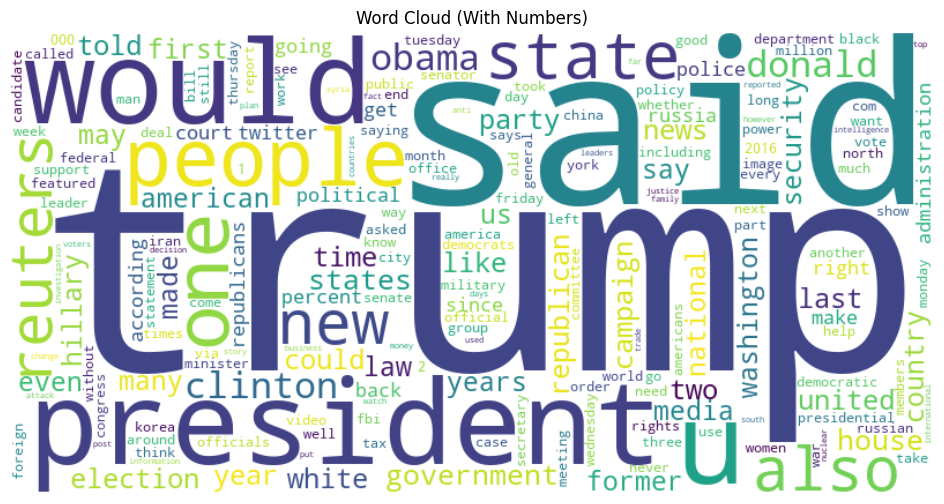

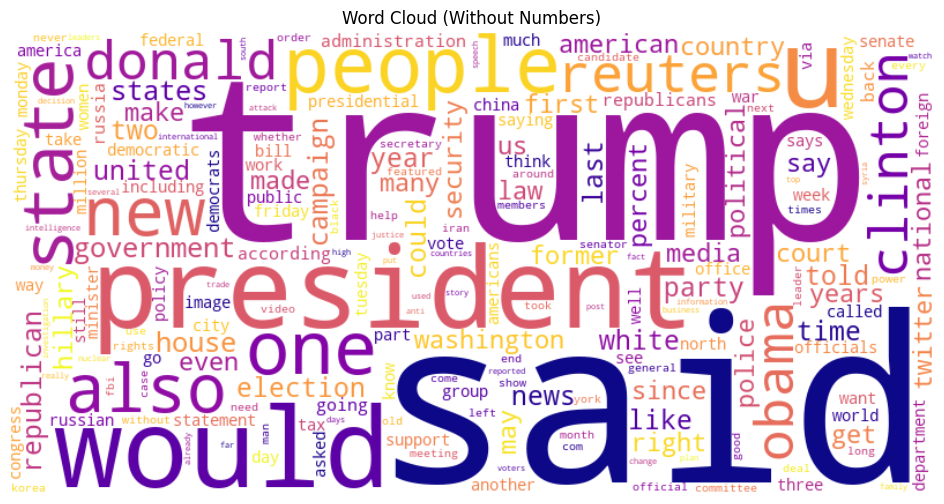

**Explanation:**
- Left Word Cloud: shows the most frequent words **including numbers**.
- Right Word Cloud: shows the most frequent words **with numbers removed**.
- Larger words indicate higher frequency in the dataset.
- Word Clouds provide an intuitive overview of common terms and their relative importance in the corpus.

In [65]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# --- Explanation above code ---
display(Markdown("### Word Cloud Visualization\n"
                 "- Word Clouds represent word frequencies visually.\n"
                 "- The size of each word is proportional to its frequency.\n"
                 "- Two Word Clouds: one for text **with numbers**, one for text **without numbers**.\n"
                 "- This provides a quick visual insight into the most common words in each dataset."))

# --- Word Cloud for text WITH numbers ---
freq_dict_with_num = dict(zip(freq_with_num['Word'], freq_with_num['Frequency']))

wordcloud_with_num = WordCloud(width=800, height=400,
                               background_color='white',
                               colormap='viridis').generate_from_frequencies(freq_dict_with_num)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_with_num, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud (With Numbers)")
plt.show()

# --- Word Cloud for text WITHOUT numbers ---
freq_dict_no_num = dict(zip(freq_no_num['Word'], freq_no_num['Frequency']))

wordcloud_no_num = WordCloud(width=800, height=400,
                             background_color='white',
                             colormap='plasma').generate_from_frequencies(freq_dict_no_num)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_no_num, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud (Without Numbers)")
plt.show()

# --- Explanation below plots ---
display(Markdown("**Explanation:**\n"
                 "- Left Word Cloud: shows the most frequent words **including numbers**.\n"
                 "- Right Word Cloud: shows the most frequent words **with numbers removed**.\n"
                 "- Larger words indicate higher frequency in the dataset.\n"
                 "- Word Clouds provide an intuitive overview of common terms and their relative importance in the corpus."))
